This notebook is for searching for the best set of hyperparameters for all methods in part 1 generalization paper.

In [1]:
# Data collection command:
# `python comet_download.py --project=generalization-paper-draft-v2-part-1-v2 --n_threads=8`

In [1]:
import itertools
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from phd.feature_search.analysis.plotting_utils import *
from phd.feature_search.analysis.plotting import plot_learning_curves, plot_param_sensitivity

sns.set_theme('notebook', 'white')
%matplotlib inline

In [2]:
# TODO: Switch to v2 data after the sweeps are run

save_path = 'figures/'
config_data_path = 'data/generalization-paper-draft-v2-part-1-v2_params.csv'
run_data_path = f'data/generalization-paper-draft-v2-part-1-v2_metrics.csv'

all_sweeps_config_df = pd.read_csv(config_data_path, index_col=0)
all_sweeps_run_df = pd.read_csv(run_data_path, index_col=0)

# Remove duplicate config rows, ignoring run_id column
all_sweeps_config_df = all_sweeps_config_df.drop_duplicates(
    subset = [col for col in all_sweeps_config_df.columns if col != 'run_id'],
    keep = 'last',
)
valid_run_ids = set(all_sweeps_config_df['run_id'].unique())
all_sweeps_run_df = all_sweeps_run_df[all_sweeps_run_df['run_id'].isin(valid_run_ids)]
all_sweeps_run_df = all_sweeps_run_df.dropna(subset=['step'])

sweep_names = list(all_sweeps_config_df['sweep_name'].unique())

# Split up dfs by sweep name
run_dfs = {}
config_dfs = {}
for sweep_name in sweep_names:
    config_dfs[sweep_name] = all_sweeps_config_df[all_sweeps_config_df['sweep_name'] == sweep_name].reset_index(drop=True)
    # Drop experiments that did not complete
    max_step = config_dfs[sweep_name]['curr_step'].max()
    config_dfs[sweep_name] = config_dfs[sweep_name][config_dfs[sweep_name]['curr_step'] == max_step]
    
    run_ids = set(config_dfs[sweep_name]['run_id'].unique())
    run_dfs[sweep_name] = all_sweeps_run_df[all_sweeps_run_df['run_id'].isin(run_ids)].reset_index(drop=True)

{k: len(v) for k, v in config_dfs.items()}

{'vary_ns_and_model_size': 720,
 'fixed_features_vary_ns': 180,
 'sgd_output_layer_vary_ns': 180}

## Autostep + Feature Search

Text(0.5, 1.0, 'Autostep + Feature Search')

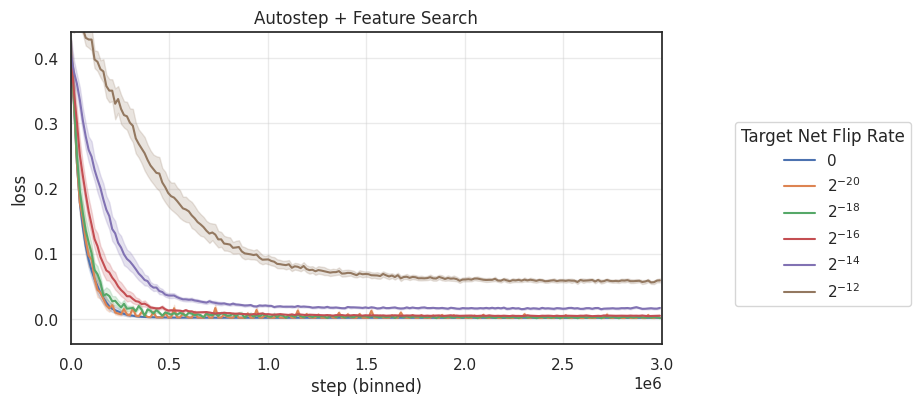

In [4]:
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['vary_ns_and_model_size'],
    config_df = config_dfs['vary_ns_and_model_size'],
    chosen_values = {'model|hidden_dim': 5120},
)

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (7, 4),
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
    show_ci = True,
)
plt.title('Autostep + Feature Search')

Text(0.5, 1.0, 'Perfect Feature Matches')

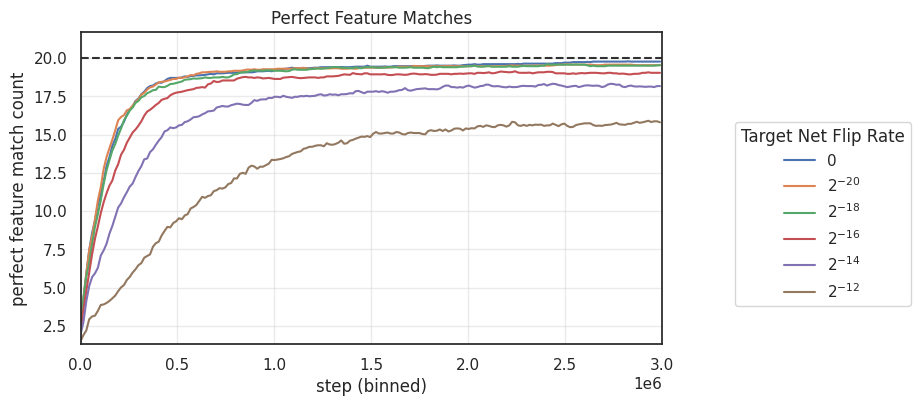

In [5]:
plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (7, 4),
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
)
plt.axhline(y=20, color='black', linestyle='--', alpha=0.8)
plt.title('Perfect Feature Matches')

## Autostep vs. SGD Output Layer

In [17]:
selected_run_df, selected_config_df = select_experiment_runs(
    run_df = run_dfs['vary_ns_and_model_size'],
    config_df = config_dfs['vary_ns_and_model_size'],
    chosen_values = {'model|hidden_dim': 5120},
)

selected_config_df = pd.concat([selected_config_df, config_dfs['sgd_output_layer_vary_ns']])
selected_run_df = pd.concat([selected_run_df, run_dfs['sgd_output_layer_vary_ns']])

selected_config_df['learning_algo'] = selected_config_df['sweep_name'].replace(
    {'vary_ns_and_model_size': 'Autostep', 'sgd_output_layer_vary_ns': 'SGD'})

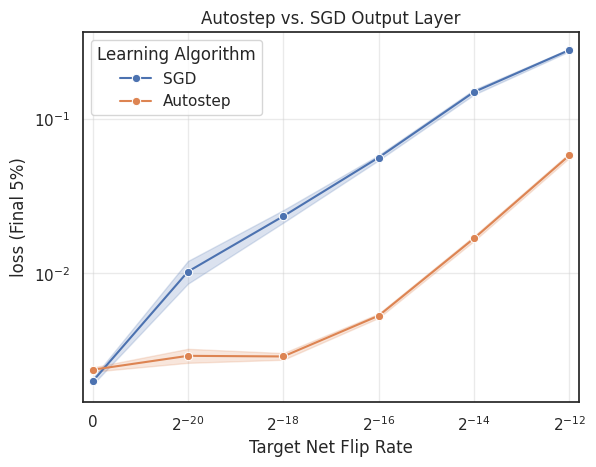

In [ ]:
plot_param_sensitivity(
    run_df = selected_run_df,
    config_df = selected_config_df,
    x_col = 'task|flip_rate',
    title = 'Autostep vs. SGD Output Layer',
    x_label = 'Target Net Flip Rate',
    y_label = 'loss',
    metric_col = 'loss',
    metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
    step_col = 'step',
    hue_col = 'learning_algo',
    legend_title = 'Learning Algorithm',
    show_ci = True,
    baseline_col = None,
    pow_2_x_axis = True,
    pow_2_legend = False,
)
plt.yscale('log')
plt.show()

plot_learning_curves(
    run_df = selected_run_df,
    config_df = selected_config_df,
    n_bins = 200,
    figsize = (12, 8),
    max_cols = 2,
    same_y_axis = True,
    subplot_col = 'task|flip_rate',
    subplot_col_label = 'Target Net Flip Rate',
    hue_col = 'learning_algo',
    pow_2_legend = False,
    legend_title = 'Learning Algorithm',
    show_ci = True,
)
plt.suptitle('Autostep vs. SGD Output Layer')
plt.show()

# Convert subplot titles to use powers of 2
for ax in plt.gcf().axes:
    title = ax.get_title()
    if ' = ' in title:
        prefix, number = title.split(' = ')
        try:
            num = float(number)
            if num != 0:
                power = int(np.log2(num))
                new_title = f"{prefix} = $2^{{{power}}}$"
                ax.set_title(new_title)
        except ValueError:
            pass # Skip if number conversion fails

plt.suptitle('Effects of Scaling')
plt.show()

## Autostep + Feature Search - Fixed Features Baseline

Text(0.5, 1.0, 'Autostep w/ Fixed Features')

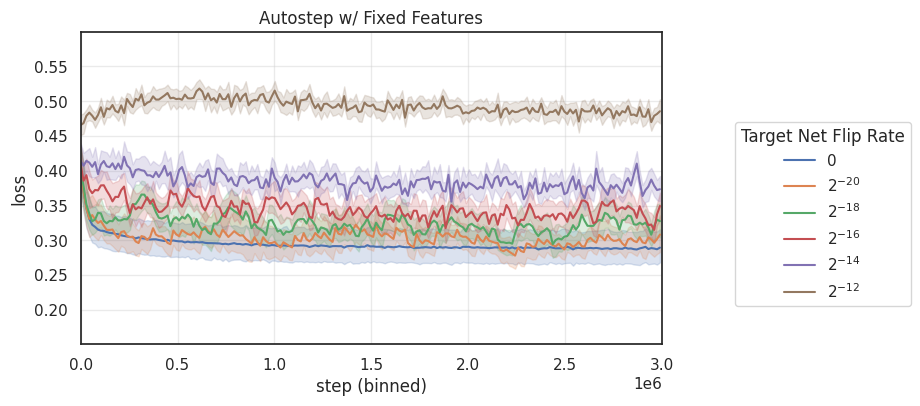

In [11]:
plot_learning_curves(
    run_df = run_dfs['fixed_features_vary_ns'],
    config_df = config_dfs['fixed_features_vary_ns'],
    n_bins = 200,
    figsize = (7, 4),
    hue_col = 'task|flip_rate',
    pow_2_legend = True,
    legend_title = 'Target Net Flip Rate',
    show_ci = True,
)
plt.title('Autostep w/ Fixed Features')

## Autostep + Feature Search - Effects of Scaling

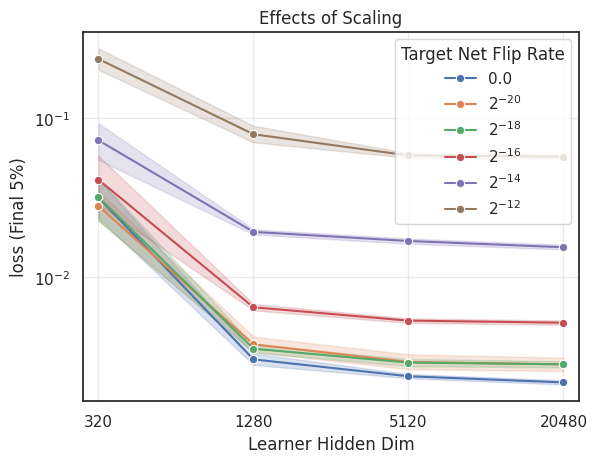

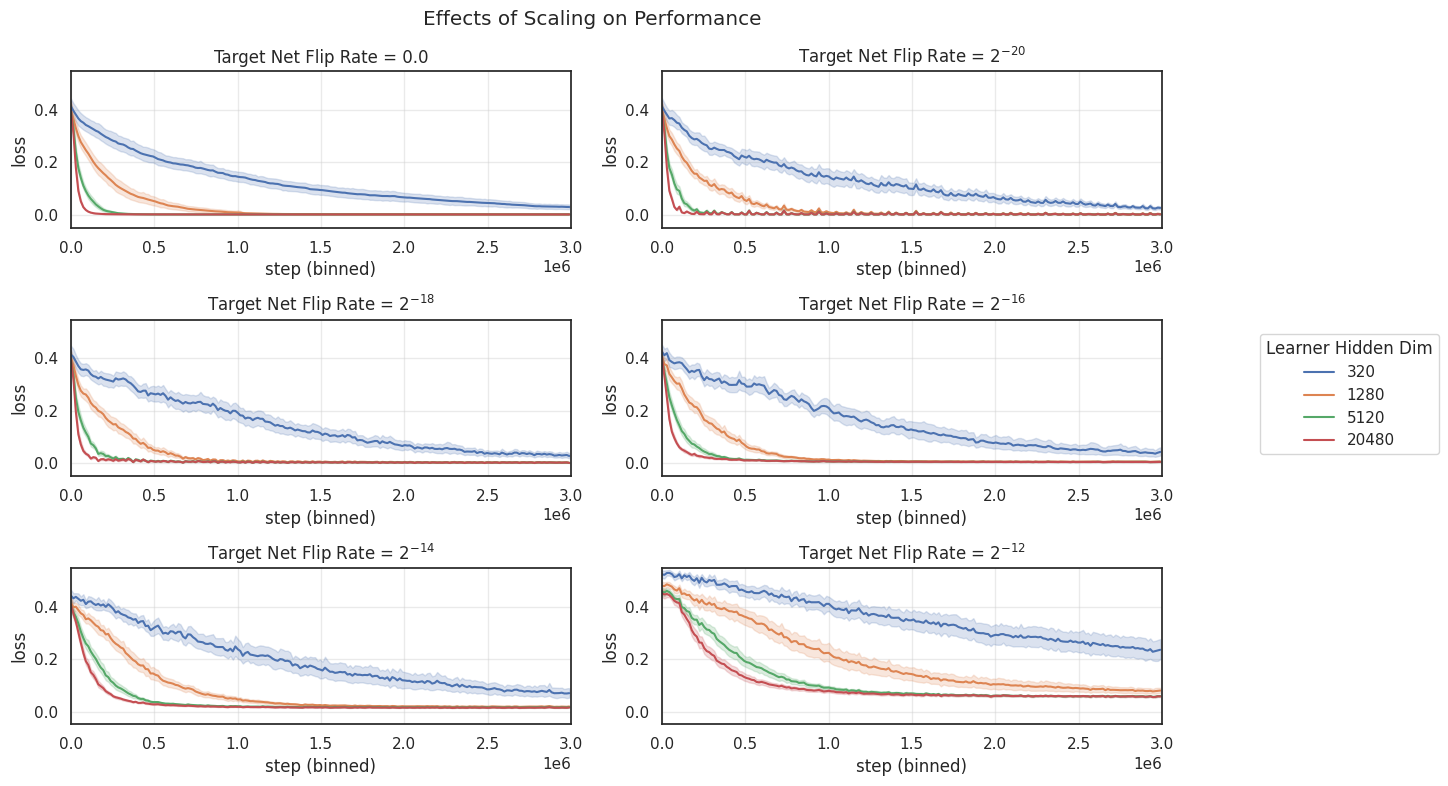

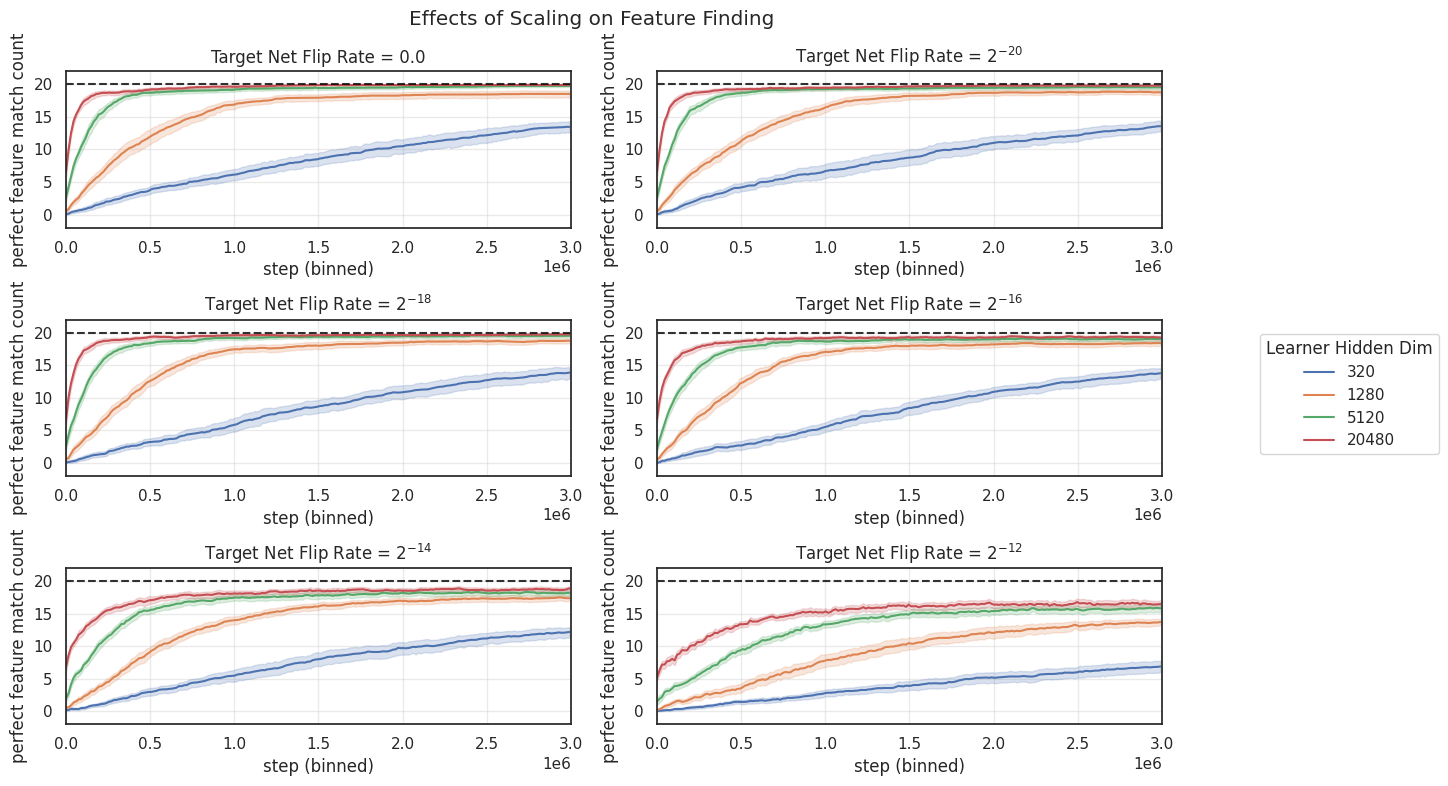

In [7]:
plot_param_sensitivity(
    run_df = run_dfs['vary_ns_and_model_size'],
    config_df = config_dfs['vary_ns_and_model_size'],
    x_col = 'model|hidden_dim',
    title = f'Effects of Scaling',
    x_label = 'Learner Hidden Dim',
    y_label = 'loss',
    metric_col = 'loss',
    metric_type = 'final_avg', # {'cumulative', 'final_avg', 'last'}
    step_col = 'step',
    hue_col = 'task|flip_rate',
    legend_title = 'Target Net Flip Rate',
    show_ci = True,
    baseline_col = None,
    pow_2_x_axis = False,
    pow_2_legend = True,
)
plt.yscale('log')
plt.show()

plot_learning_curves(
    run_df = run_dfs['vary_ns_and_model_size'],
    config_df = config_dfs['vary_ns_and_model_size'],
    n_bins = 200,
    figsize = (12, 8),
    max_cols = 2,
    same_y_axis = True,
    subplot_col = 'task|flip_rate',
    subplot_col_label = 'Target Net Flip Rate',
    hue_col = 'model|hidden_dim',
    pow_2_legend = False,
    legend_title = 'Learner Hidden Dim',
    show_ci = True,
)

# Convert subplot titles to use powers of 2
for ax in plt.gcf().axes:
    title = ax.get_title()
    if ' = ' in title:
        prefix, number = title.split(' = ')
        try:
            num = float(number)
            if num != 0:
                power = int(np.log2(num))
                new_title = f"{prefix} = $2^{{{power}}}$"
                ax.set_title(new_title)
        except ValueError:
            pass # Skip if number conversion fails

plt.suptitle('Effects of Scaling on Performance')
plt.show()


plot_learning_curves(
    run_df = run_dfs['vary_ns_and_model_size'],
    config_df = config_dfs['vary_ns_and_model_size'],
    n_bins = 200,
    figsize = (12, 8),
    max_cols = 2,
    same_y_axis = True,
    subplot_col = 'task|flip_rate',
    subplot_col_label = 'Target Net Flip Rate',
    y_col = 'feature_match/perfect_match_count',
    y_label = 'perfect feature match count',
    hue_col = 'model|hidden_dim',
    pow_2_legend = False,
    legend_title = 'Learner Hidden Dim',
    show_ci = True,
)

# Convert subplot titles to use powers of 2 and add horizontal line to each subplot
for ax in plt.gcf().axes:
    title = ax.get_title()
    if ' = ' in title:
        prefix, number = title.split(' = ')
        try:
            num = float(number)
            if num != 0:
                power = int(np.log2(num))
                new_title = f"{prefix} = $2^{{{power}}}$"
                ax.set_title(new_title)
        except ValueError:
            pass # Skip if number conversion fails
    # Add horizontal line at y=20 to each subplot as per file_context_0
    ax.axhline(y=20, color='black', linestyle='--', alpha=0.8)

plt.suptitle('Effects of Scaling on Feature Finding')
plt.show()